# ARTIQ on RISC-Q: two DACs, four DDS channels, two ADC traces

Both experiments below are written EXACTLY as ARTIQ experiments — `EnvExperiment`,
`build`/`run`/`analyze`, `setattr_device`, `@kernel`, bare `with parallel:` / `with sequential:` and
bare `delay()` — with RISC-Q's own kernel compiler underneath (`riscq.artiq_compat`). They run LIVE on
the RFSoC 4x2 with the `rfsoc4x2-2q-fine` bitstream, whose channels are:

| device_db entry | what it is | connector |
|---|---|---|
| `dds` channel 0 / 1 | hardware core 0's gate / readout drive (summed on one DAC) | **DAC_A** |
| `dds` channel 2 / 3 | hardware core 1's gate / readout drive | **DAC_B** |
| `adc` channel 0 | raw trace of ADC_A — records while dds 1 fires | **ADC_A** |
| `adc` channel 1 | raw trace of ADC_B — records while dds 3 fires | **ADC_B** |
| `demod` channel 0 / 1 | IQ readout of core 0 / core 1 (ADC_A / ADC_B) | |

Bench wiring for this notebook: **DAC_A → ADC_A** and **DAC_B → ADC_B** (two loopback cables).

1. **DAC_A plays the reference waveform** (`reference/waveform_generator.py`, the two-pulse ion-trap
   sequence); ADC_A records it and the capture is overlaid on the generator point by point.
2. **Four DDS channels on one timeline**: both DACs play the same two-tone pulse together, then a single
   tone with a programmed phase difference between the DACs; ADC_A and ADC_B record both.


In [1]:
import sys
sys.path[:0] = ["../client", "../../sim"]      # riscq (client) + riscq_sim (co-sim)
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

from riscq.artiq_compat import *


class IonTrap(EnvExperiment):
    def build(self):
        self.setattr_device("core")
        self.setattr_device("gate_dds")
        self.setattr_device("ro_dds")
        self.setattr_device("adc")

    @kernel
    def run(self):
        self.core.reset()
        with parallel:
            with sequential:                            # send: the two-pulse sequence
                with parallel:
                    with sequential:
                        self.gate_dds.set(83.765*MHz, phase=0.0, amplitude=0.4)
                        self.gate_dds.sw.pulse(100*us)
                    with sequential:
                        self.ro_dds.set(80.235*MHz, phase=0.5, amplitude=0.4)
                        self.ro_dds.sw.pulse(100*us)
                delay(5*us)
                self.ro_dds.set(82.0*MHz, phase=0.25, amplitude=0.4,
                                phase_mode=PHASE_MODE_ABSOLUTE)
                self.ro_dds.sw.pulse(20*us)
            with sequential:                            # receive: record while it plays
                self.adc.gate(125*us)

    def analyze(self):
        self.trace = self.adc.fetch_trace()             # <- the raw ADC samples


In [2]:
device_db = {
    "core":     {"type": "board", "host": "192.168.3.1", "bundle": "rfsoc4x2-2q-fine"},
    "gate_dds": {"type": "dds", "channel": 0},          # core 0's gate drive    -> DAC_A
    "ro_dds":   {"type": "dds", "channel": 1},          # core 0's readout drive -> DAC_A
    "adc":      {"type": "adc", "channel": 0},          # ADC_A (records while ro_dds fires)
}
# The same experiment against the co-simulation instead of the board (no hardware needed):
# device_db["core"] = {"type": "cosim", "config": "../../gateware/configs/rfsoc4x2-2q-fine.json",
#                      "build": "../../sim/build/rfsoc4x2-2q-fine",
#                      "model": {"kind": "loopback", "src": 1, "dst": 1, "gain": 0.9, "delay": 5}}

exp = run_experiment(IonTrap, device_db)                # the artiq_run role, live
x, fs = exp.trace.astype(float), exp.last_result.fs
x -= x[:300].mean()                                     # remove the ADC's small DC offset
t = np.arange(x.size) / fs
print(f"{x.size} ADC samples at {fs/1e9:.5f} GS/s = {x.size/fs*1e6:.1f} us")


245760 ADC samples at 1.96608 GS/s = 125.0 us


delay D = 192.615 ns, scale = 6302 code/unit
in-pulse: signal rms 6053 code, residual rms 36 code (0.60 %)
carrier phase, capture vs generator @ 83.765 MHz: -0.24 deg
carrier phase, capture vs generator @ 80.235 MHz: +0.28 deg
carrier phase, capture vs generator @ 82.000 MHz: +0.00 deg


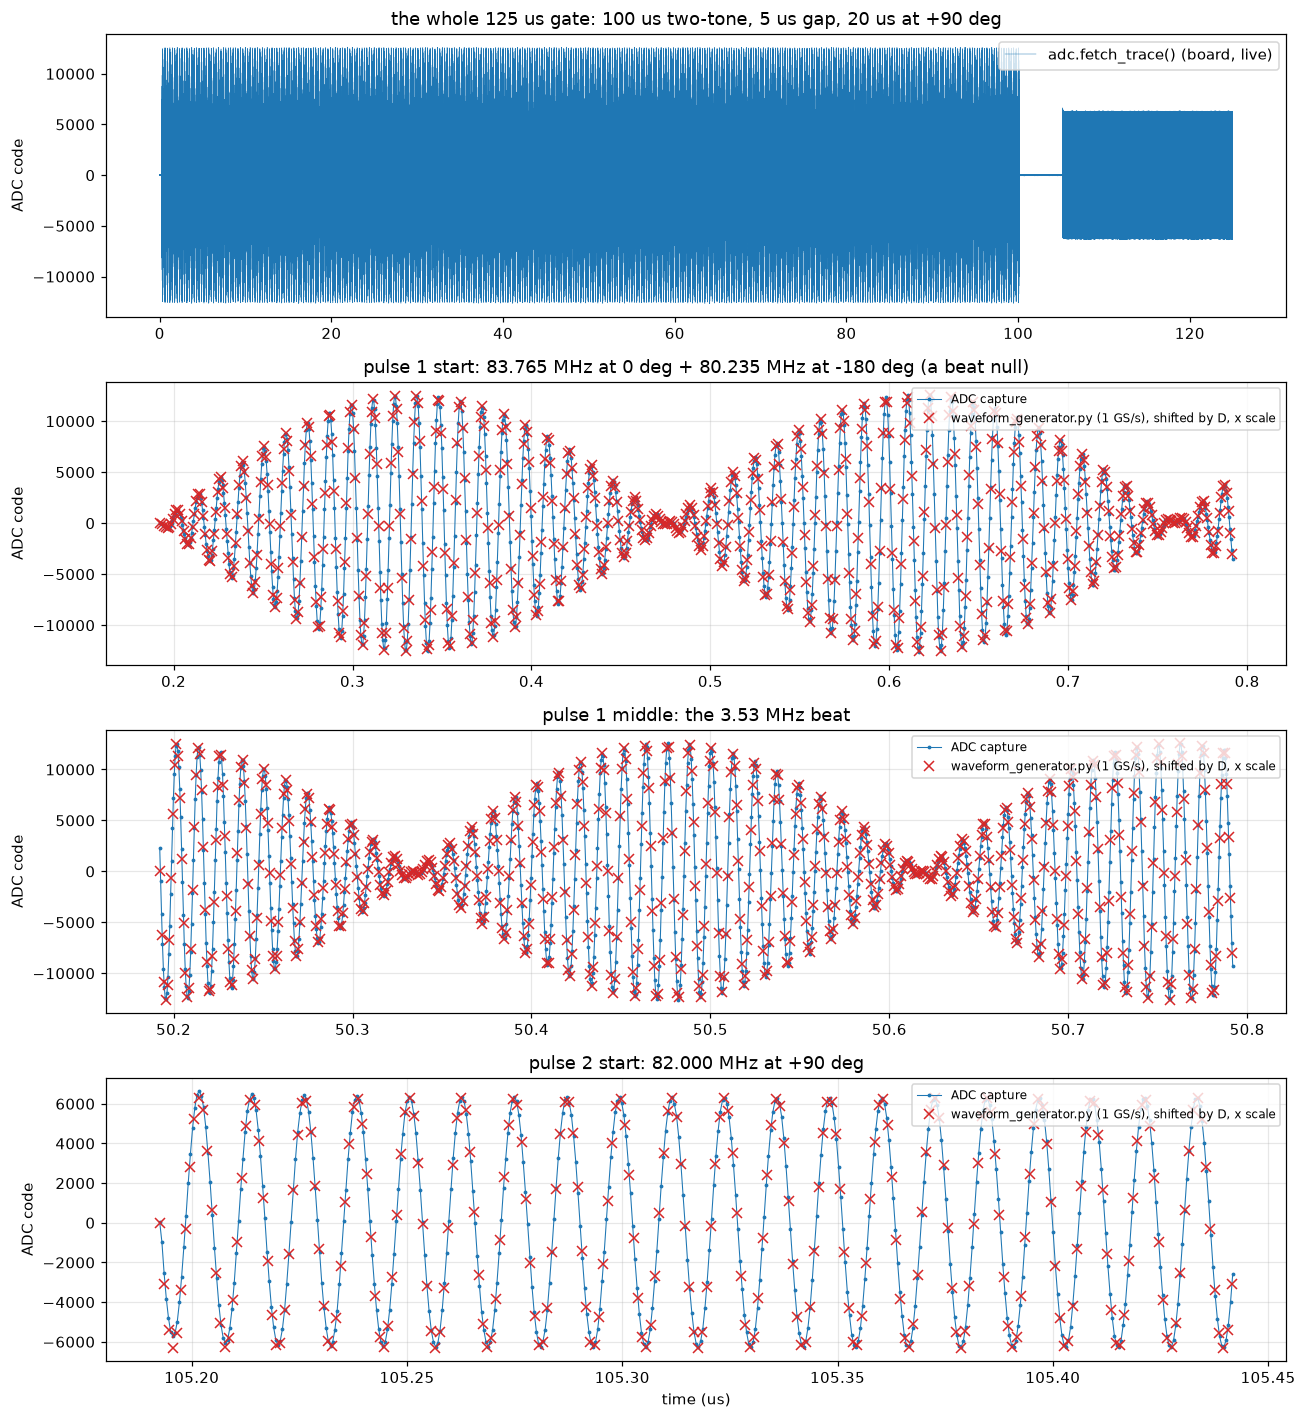

In [3]:
# overlay the capture on reference/waveform_generator.py's waveform
orig = np.load("reference/waveform.npz")                 # the generator at 1 GS/s
t_o, w_o = orig["time_us"] * 1e-6, orig["waveform"]

def phi(sig, tt, f, lo_s, hi_s):                     # tone phase over a window
    r = 1.0 / (tt[1] - tt[0])
    sl = slice(int(lo_s * r), int(hi_s * r))
    return np.angle(np.sum(sig[sl] * np.exp(-2j*np.pi*f*tt[sl])))

pad = 262500                                         # 1 GS/s -> fs lands on integers
W = np.fft.rfft(np.concatenate((w_o, np.zeros(pad - w_o.size))))
f_ax = np.fft.rfftfreq(pad, 1e-9)
n2 = round(pad * fs / 1e9)
def resample(D):                                     # the generator on the ADC grid, delayed by D
    R2 = np.zeros(n2 // 2 + 1, complex)
    R2[:W.size] = W * np.exp(-2j * np.pi * f_ax * D)
    return (np.fft.irfft(R2, n2) * (n2 / pad))[:x.size]

# end-to-end delay: the 82 MHz phase in pulse 2 fixes D modulo one carrier cycle;
# the residual picks the cycle (pulse 1 starts on a beat null, so the onset alone cannot)
f2, on = 82e6, np.argmax(np.abs(x) > max(6 * x[:300].std(), 0.05 * np.abs(x).max()))
Df = (t[on] + ((phi(w_o, t_o, f2, 106e-6, 118e-6) - phi(x, t, f2, 106e-6, 118e-6))
               / (2*np.pi*f2) - t[on] + 0.5/f2) % (1/f2)) - 0.5/f2
best = None
for k in range(-6, 7):
    Dk = Df + k / f2
    r = resample(Dk)
    sl = slice(int((40e-6 + Dk)*fs), int((60e-6 + Dk)*fs))
    sc = np.dot(x[sl], r[sl]) / np.dot(r[sl], r[sl])
    rms = np.sqrt(np.mean((x[sl] - sc * r[sl])**2))
    if best is None or rms < best[0]:
        best = (rms, Dk, sc)
_, D, scale = best
ref = scale * resample(D)

inp = np.r_[int((1e-6+D)*fs):int((99e-6+D)*fs), int((106e-6+D)*fs):int((124e-6+D)*fs)]
print(f"delay D = {D*1e9:.3f} ns, scale = {scale:.0f} code/unit")
print(f"in-pulse: signal rms {np.sqrt(np.mean(x[inp]**2)):.0f} code, residual rms "
      f"{np.sqrt(np.mean((x-ref)[inp]**2)):.0f} code "
      f"({100*np.sqrt(np.mean((x-ref)[inp]**2)/np.mean(x[inp]**2)):.2f} %)")
for name, f0, lo, hi in (("83.765", 83.765e6, 2e-6, 98e-6), ("80.235", 80.235e6, 2e-6, 98e-6),
                         ("82.000", 82.0e6, 106e-6, 118e-6)):
    d = np.degrees(((phi(x, t, f0, lo+D, hi+D) - phi(ref, t, f0, lo+D, hi+D) + np.pi)
                    % (2*np.pi)) - np.pi)
    print(f"carrier phase, capture vs generator @ {name} MHz: {d:+.2f} deg")

fig, ax = plt.subplots(4, 1, figsize=(12, 13))
ax[0].plot(t*1e6, x, lw=0.3, color="C0", label="adc.fetch_trace() (board, live)")
ax[0].set_title("the whole 125 us gate: 100 us two-tone, 5 us gap, 20 us at +90 deg")
ax[0].set_ylabel("ADC code"); ax[0].legend(loc="upper right")
for a, (t0, w, title) in zip(ax[1:], (
        (0.0, 0.6, "pulse 1 start: 83.765 MHz at 0 deg + 80.235 MHz at -180 deg (a beat null)"),
        (50.0, 0.6, "pulse 1 middle: the 3.53 MHz beat"),
        (105.0, 0.25, "pulse 2 start: 82.000 MHz at +90 deg"))):
    sl = slice(int((t0*1e-6 + D)*fs), int(((t0+w)*1e-6 + D)*fs))
    a.plot(t[sl]*1e6, x[sl], ".-", ms=3, lw=0.7, color="C0", label="ADC capture")
    mm = (t_o + D >= t[sl][0]) & (t_o + D <= t[sl][-1])
    a.plot((t_o[mm] + D)*1e6, scale*w_o[mm], "x", ms=6, color="C3",
           label="waveform_generator.py (1 GS/s), shifted by D, x scale")
    a.set_title(title); a.set_ylabel("ADC code"); a.legend(loc="upper right", fontsize=8)
    a.grid(alpha=0.3)
ax[-1].set_xlabel("time (us)")
plt.tight_layout(); plt.show()

## 2. Four DDS channels, two DACs, one timeline

The experiment below drives both DACs. Everything directly under one `with parallel:` starts at the
same instant and each `with sequential:` arm is one channel's story; `self.core` is still ONE device —
the timeline is shared — and `run_experiment` compiles one kernel per hardware core from it. The two
kernels anchor on one hardware time origin (latched when the cores are released from reset), so pulses
scheduled at the same instant start on the same 2.035 ns batch on both DACs, and the phases you ask for
are relative phases between the DACs.

What to look at in the plots:

* the envelope cross-correlation lag between the two traces stays within a batch (4 samples = 2.035 ns,
  which would be 60° at 82 MHz — obvious at that zoom): the digital timeline is exact across the two
  cores. The lag is measured on the envelopes, not on a threshold, because a lossy cable lowers one
  trace's level and would otherwise look like a timing offset (a lossy cable once shifted an envelope
  here by 3 samples; with identical cables the lag is 0);
* in the second pulse DAC_B was asked for +0.25 turns relative to DAC_A: the measured difference is
  90° plus a constant. That constant is the fixed path difference between the two DAC connectors
  and the two cables (about 1.5° at 82 MHz with two identical cables; a mismatched cable on one loop
  once turned it into 67° and 7 dB of level — the level ratio is printed so that shows): this bundle
  multi-tile-synchronizes the RF tiles at every load (the `board_info` line below shows the MTS
  result and the tile latencies pinned to the values in the bundle's `board.json`), which removes
  the per-load converter-latency part of that constant; the analog part is whatever your cables and
  connectors are. Measure the constant with a loopback like this one, at the frequency you use, and
  re-measure after a power cycle before relying on it; then fold it into the `phase` of the DAC_B
  channels if you need the connectors, not only the timeline, aligned.


In [4]:
class TwoDacSync(EnvExperiment):
    def build(self):
        self.setattr_device("core")
        for name in ("dds_a0", "dds_a1", "dds_b0", "dds_b1", "adc_a", "adc_b"):
            self.setattr_device(name)

    @kernel
    def run(self):
        self.core.reset()
        with parallel:
            # DAC_A: two tones for 40 us; 5 us later a 20 us tone at 82 MHz, phase 0
            with sequential:
                self.dds_a0.set(83.765*MHz, phase=0.0, amplitude=0.4)
                self.dds_a0.sw.pulse(40*us)
            with sequential:
                self.dds_a1.set(80.235*MHz, phase=0.5, amplitude=0.4)
                self.dds_a1.sw.pulse(40*us)
                delay(5*us)
                self.dds_a1.set(82.0*MHz, phase=0.0, amplitude=0.4)
                self.dds_a1.sw.pulse(20*us)
            # DAC_B: the same sequence, its last tone asked +0.25 turns (90 deg) ahead of DAC_A's
            with sequential:
                self.dds_b0.set(83.765*MHz, phase=0.0, amplitude=0.4)
                self.dds_b0.sw.pulse(40*us)
            with sequential:
                self.dds_b1.set(80.235*MHz, phase=0.5, amplitude=0.4)
                self.dds_b1.sw.pulse(40*us)
                delay(5*us)
                self.dds_b1.set(82.0*MHz, phase=0.25, amplitude=0.4)
                self.dds_b1.sw.pulse(20*us)
            # record both ADCs over the whole sequence
            with sequential:
                self.adc_a.gate(70*us)
            with sequential:
                self.adc_b.gate(70*us)

    def analyze(self):
        self.trace_a = self.adc_a.fetch_trace()
        self.trace_b = self.adc_b.fetch_trace()


device_db2 = {
    "core":   {"type": "board", "host": "192.168.3.1", "bundle": "rfsoc4x2-2q-fine"},
    "dds_a0": {"type": "dds", "channel": 0},    # DAC_A
    "dds_a1": {"type": "dds", "channel": 1},    # DAC_A
    "dds_b0": {"type": "dds", "channel": 2},    # DAC_B
    "dds_b1": {"type": "dds", "channel": 3},    # DAC_B
    "adc_a":  {"type": "adc", "channel": 0},    # ADC_A, records while dds_a1 fires
    "adc_b":  {"type": "adc", "channel": 1},    # ADC_B, records while dds_b1 fires
}
exp2 = run_experiment(TwoDacSync, device_db2)
r2 = exp2.last_result
print(f"shared time origin t1 = {r2.origin} (batches); per-core telemetry [t1, entry, armed]:",
      {k: list(map(int, c.tele[:3])) for k, c in r2.cores.items()})
print("board_info:", {k: exp2.board_info[k] for k in ("bundle", "mts_result", "mts_latencies", "dsp_mhz")})


shared time origin t1 = 2054626957 (batches); per-core telemetry [t1, entry, armed]: {0: [2054626957, 2054618838, 2054619088], 1: [2054626957, 2054618838, 2054619088]}
board_info: {'bundle': 'rfsoc4x2-2q-fine', 'mts_result': 0, 'mts_latencies': ({0: 260, 2: 260}, {2: 88}), 'dsp_mhz': 491.49}


envelope of ADC_A lags ADC_B by 0 samples = +0 ps (one ADC sample = 509 ps, one batch = 2035 ps; 0 = the two DACs started on the same batch)
82 MHz level ratio ADC_B / ADC_A = 0.980 (-0.2 dB) — a lossy or mismatched cable shows up here first and also bends the phase below, so measure the offset at the frequency you use
DAC_B - DAC_A carrier phase: pulse 1 @ 83.765 MHz +1.39 deg (asked 0), pulse 2 @ 82 MHz +91.28 deg (asked +90) -> analog offset between the DAC paths ~+1.39 deg / +1.28 deg


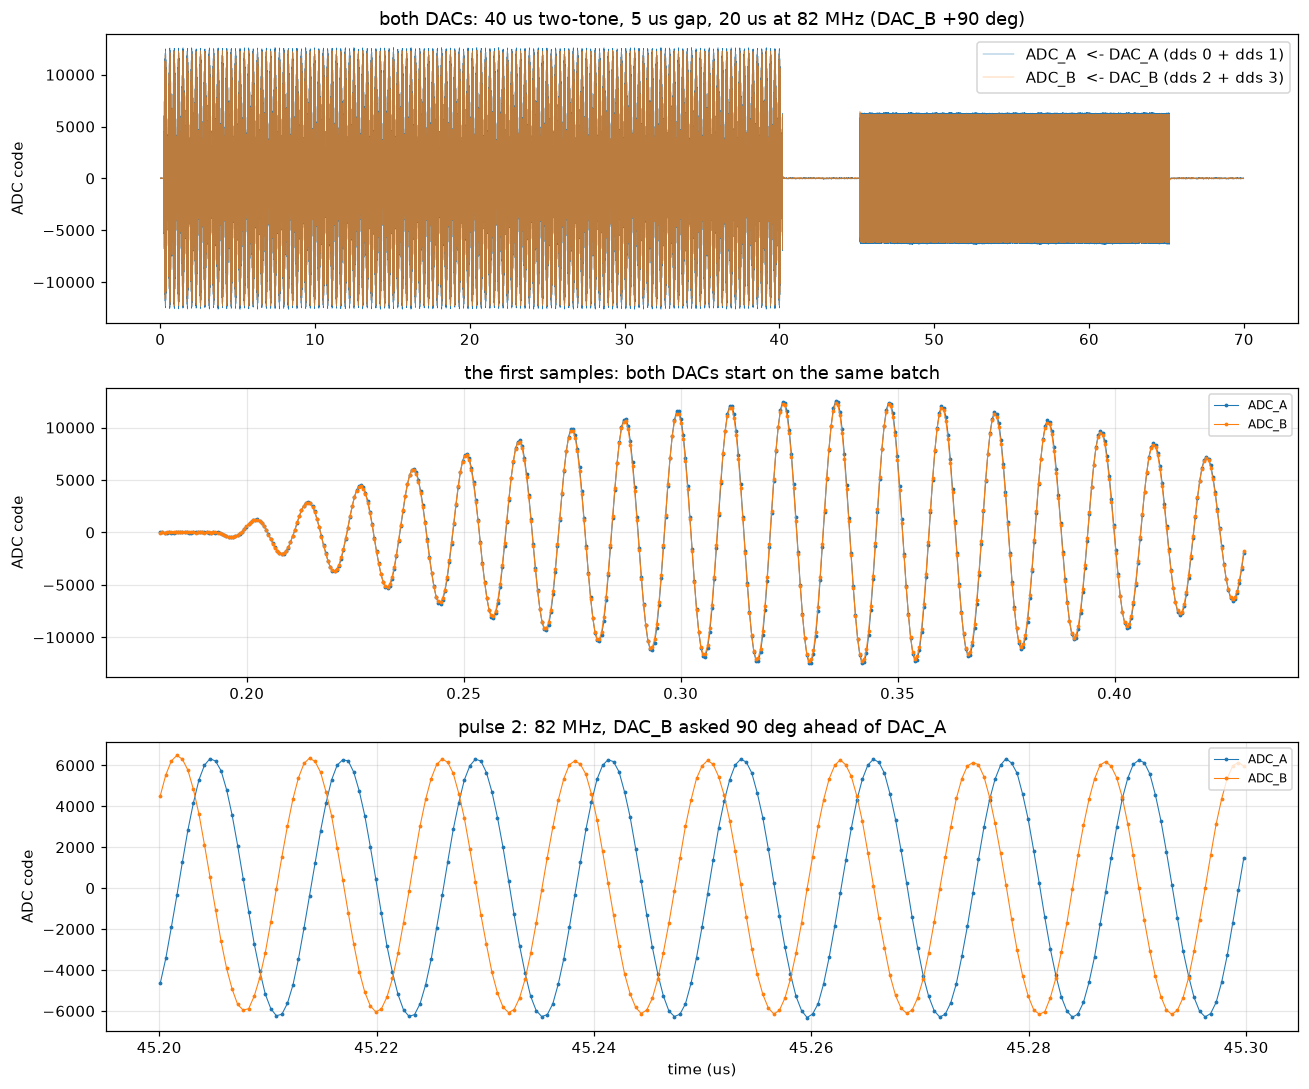

In [5]:
xa, xb = exp2.trace_a.astype(float), exp2.trace_b.astype(float)
xa -= xa[:300].mean(); xb -= xb[:300].mean()
fs = r2.fs; t = np.arange(xa.size) / fs

def onset(x):                                        # first sample clearly above the noise (plot windows)
    return int(np.argmax(np.abs(x) > max(6 * x[:300].std(), 0.05 * np.abs(x).max())))

def envelope_lag(x, y, f):                           # lag of x's envelope behind y's, in samples
    k = max(2, int(round(fs / f)))                   # |x| smoothed over one carrier period
    ex = np.convolve(np.abs(x), np.ones(k) / k, "same"); ey = np.convolve(np.abs(y), np.ones(k) / k, "same")
    ex -= ex.mean(); ey -= ey.mean()
    return int(np.argmax(np.correlate(ex, ey, "full"))) - (ey.size - 1)

def phi(x, f, lo_s, hi_s):                           # tone phase over a window
    sl = slice(int(lo_s * fs), int(hi_s * fs))
    return np.angle(np.sum(x[sl] * np.exp(-2j*np.pi*f*t[sl])))

def wrap(deg):
    return (deg + 180) % 360 - 180

on_a, on_b = onset(xa), onset(xb)
lag = envelope_lag(xa, xb, 82e6)
print(f"envelope of ADC_A lags ADC_B by {lag} samples = {lag / fs * 1e12:+.0f} ps "
      f"(one ADC sample = {1e12/fs:.0f} ps, one batch = {4e12/fs:.0f} ps; 0 = the two DACs started on the same batch)")
amp_a = np.abs(np.sum(xa[int(47e-6*fs):int(63e-6*fs)] * np.exp(-2j*np.pi*82e6*t[int(47e-6*fs):int(63e-6*fs)])))
amp_b = np.abs(np.sum(xb[int(47e-6*fs):int(63e-6*fs)] * np.exp(-2j*np.pi*82e6*t[int(47e-6*fs):int(63e-6*fs)])))
print(f"82 MHz level ratio ADC_B / ADC_A = {amp_b / amp_a:.3f} ({20*np.log10(amp_b/amp_a):+.1f} dB) — a lossy or mismatched "
      f"cable shows up here first and also bends the phase below, so measure the offset at the frequency you use")
d1 = wrap(np.degrees(phi(xb, 83.765e6, 3e-6, 38e-6) - phi(xa, 83.765e6, 3e-6, 38e-6)))
d2 = wrap(np.degrees(phi(xb, 82.0e6, 47e-6, 63e-6) - phi(xa, 82.0e6, 47e-6, 63e-6)))
print(f"DAC_B - DAC_A carrier phase: pulse 1 @ 83.765 MHz {d1:+.2f} deg (asked 0), "
      f"pulse 2 @ 82 MHz {d2:+.2f} deg (asked +90) -> analog offset between the DAC paths "
      f"~{d1:+.2f} deg / {wrap(d2 - 90):+.2f} deg")

fig, ax = plt.subplots(3, 1, figsize=(12, 10))
ax[0].plot(t*1e6, xa, lw=0.3, label="ADC_A  <- DAC_A (dds 0 + dds 1)")
ax[0].plot(t*1e6, xb, lw=0.3, label="ADC_B  <- DAC_B (dds 2 + dds 3)", alpha=0.7)
ax[0].set_title("both DACs: 40 us two-tone, 5 us gap, 20 us at 82 MHz (DAC_B +90 deg)")
ax[0].set_ylabel("ADC code"); ax[0].legend(loc="upper right")
for a, (t0, w, title) in zip(ax[1:], (
        (t[on_a] * 1e6 - 0.02, 0.25, "the first samples: both DACs start on the same batch"),
        (45.0 + t[on_a] * 1e6, 0.1, "pulse 2: 82 MHz, DAC_B asked 90 deg ahead of DAC_A"))):
    sl = slice(int(t0 * 1e-6 * fs), int((t0 + w) * 1e-6 * fs))
    a.plot(t[sl]*1e6, xa[sl], ".-", ms=3, lw=0.7, label="ADC_A")
    a.plot(t[sl]*1e6, xb[sl], ".-", ms=3, lw=0.7, label="ADC_B")
    a.set_title(title); a.set_ylabel("ADC code"); a.legend(loc="upper right", fontsize=8); a.grid(alpha=0.3)
ax[-1].set_xlabel("time (us)")
plt.tight_layout(); plt.show()
